# Chronos-2 vs Chronos-T5 — Edge-Case Robustness (corrupted sensor input)

**Saudi Aramco — time-series foundation-model evaluation**

Industrial sensor streams are rarely clean: they carry **glitch spikes**, **calibration
drift**, and **dropout gaps**. This notebook stress-tests how gracefully the two
zero-shot forecasters degrade when their *input context* is corrupted, while the true
future they are scored against stays clean.

Corruptions are injected into the **forecast context only** (see `perturbations.py`):

1. **Noisy sensor spikes** — sparse, large impulse outliers (sensor glitches / bit flips).
2. **Signal drift** — a slow additive ramp (calibration drift / baseline wander).
3. **Missing data chunks** — a contiguous block set to NaN (sensor dropout).

> **Headline = relative degradation** = `metric(corrupted) / metric(clean)`, per model,
> geometric-mean across datasets. **1.0 = no degradation; lower = more robust.** Because
> every score is normalised by that model's own clean-context score, this isolates
> *robustness* independently of the baseline accuracy gap — which lives in the parent
> zero-shot head-to-head (`../`, i.e. `chronos2_t5/zero-shot/`).
>
> Heavy work (both models × 5 datasets × conditions) is produced offline by
> `run_edge_cases.py`; this notebook loads `./results/` and runs one small live demo.


## 1. Environment & imports

This study lives in `chronos2_t5/zero-shot/edge-case/`; its logic (`run_edge_cases`,
`perturbations`) reuses the shared Chronos-2 harness in `../../../Chronos2/src/`. The notebook
only orchestrates and displays.

In [1]:
import sys, platform, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
import datasets; datasets.logging.set_verbosity_error(); datasets.disable_progress_bars()

# Locate the edge-case dir portably (the one holding run_edge_cases.py), then add it + the
# shared Chronos2 harness to the path. run_edge_cases also adds the harness itself on import.
_here = Path.cwd()
for _c in (_here, *_here.parents):
    if (_c / "run_edge_cases.py").exists():
        EDGE_DIR = _c; break
    if (_c / "edge-case" / "run_edge_cases.py").exists():
        EDGE_DIR = _c / "edge-case"; break
else:
    raise FileNotFoundError("edge-case dir (run_edge_cases.py) not found from " + str(_here))
sys.path.insert(0, str(EDGE_DIR))
sys.path.insert(0, str(EDGE_DIR.parents[2] / "Chronos2" / "src"))

import numpy as np, pandas as pd, torch
from scipy.stats import gmean
import matplotlib.pyplot as plt
from IPython.display import Image, display

import run_edge_cases as E          # study config (datasets, severities, families) + forecasters
import perturbations as P

EDGE = E.OUT                        # results dir (chronos2_t5/edge-case/results/)
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("datasets:", [d for d, _ in E.EDGE_DATASETS], "| cap:", E.EDGE_MAX_SERIES)
print("severities:", E.SEVERITIES)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

torch: 2.9.1+cu128 | CUDA: True
datasets: ['ercot', 'monash_traffic', 'monash_australian_electricity', 'monash_weather', 'nn5'] | cap: 100
severities: {'spikes_intensity': [1.0, 2.0, 4.0, 6.0, 8.0, 12.0, 16.0, 20.0, 30.0, 40.0], 'spikes_density': [0.01, 0.02, 0.05, 0.08, 0.12, 0.16, 0.2, 0.3, 0.4], 'drift': [0.5, 1.0, 2.0, 4.0, 6.0, 9.0, 12.0, 16.0, 20.0, 26.0, 32.0], 'drift_step': [0.5, 1.0, 2.0, 4.0, 8.0, 12.0, 16.0, 20.0], 'gap': [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]}


## 2. Method

* **Datasets** — high-frequency, continuous *sensor-like* Benchmark II datasets, where
  spikes / drift / dropout are physically meaningful (energy, traffic, electricity,
  weather, ATM cash), capped to `EDGE_MAX_SERIES` series each.
* **Corruption is on the context only** — the held-out future is untouched, so the metric
  measures *forecast-of-the-true-future given a corrupted input*.
* **Identical inputs to both models** — byte-for-byte the same corrupted contexts (seeded)
  are fed to Chronos-2 and Chronos-T5.
* **Metrics** — gluonts MASE + WeightedSumQuantileLoss on the same 9-quantile grid, both
  models bf16. Chronos-T5 keeps its seeded 20-sample decode; Chronos-2 uses its native
  deterministic quantile head (and ingests NaN gaps without imputation).

**What "severity" means per corruption family** (magnitudes are in units of each series'
own robust scale = MAD, so a level is comparable across datasets with different units):

| family | what is injected | severity = |
| --- | --- | --- |
| `spikes_intensity` | spike **magnitude** swept, density fixed (5% of points) | x scale (5, 10, 20) |
| `spikes_density` | spike **count** swept (fraction of points), magnitude fixed (x20) | fraction (2, 5, 10%) |
| `drift` | gradual linear ramp across the whole context, reaching `± severity × scale` at the origin | ramp end-offset (2, 5, 10) |
| `drift_step` | a **random 30%-of-context segment** level-shifted by `± severity × scale` (localised bias jump that recovers) | offset size (2, 5, 10) |
| `gap` | a contiguous run = `severity` fraction of the context, blanked to NaN at a **random position** | fraction blanked (0.1, 0.25, 0.5) |

Spikes are two **controlled-variable** sweeps (intensity vs density). `drift` vs `drift_step`:
a *slow ramp over the whole context* (reaching the origin) vs a *localised level shift of a
random past segment* (recovers before the origin). **Placement matters:** the ramp corrupts the
recent context the model anchors to; the random segment / random gap usually do not — which is
why their degradation is tiny (see §4-5).

In [2]:
cond = pd.DataFrame(E.CONDITIONS, columns=["family", "severity"])
print(f"{len(E.CONDITIONS)} conditions per (model, dataset): "
      f"1 clean + {len(E.FAMILIES)} families x 3 severities")
cond

48 conditions per (model, dataset): 1 clean + 5 families x 3 severities


,family,severity
0,clean,0.0000
1,spikes_intensity,1.0000
2,spikes_intensity,2.0000
3,spikes_intensity,4.0000
4,spikes_intensity,6.0000
5,spikes_intensity,8.0000
6,spikes_intensity,12.0000
7,spikes_intensity,16.0000
8,spikes_intensity,20.0000
9,spikes_intensity,30.0000


## 3. Results (precomputed)

Loaded from `results/edge_case_results.csv` — per `(dataset, model, family,
severity)`: absolute MASE/WQL and the degradation ratio vs that model's clean context.

In [3]:
raw = pd.read_csv(EDGE / "edge_case_results.csv")
print(f"{len(raw)} rows | models: {sorted(raw['model'].unique())}")
raw.head(12)

480 rows | models: ['chronos-2', 'chronos-t5']


,dataset,model,family,severity,MASE,WQL,n_series,latency_s,MASE_clean,WQL_clean,MASE_degr,WQL_degr
0,ercot,chronos-2,clean,0.0000,0.8418,0.0260,8,0.7200,0.8418,0.0260,1.0000,1.0000
1,ercot,chronos-2,spikes_intensity,1.0000,0.8319,0.0246,8,0.0820,0.8418,0.0260,0.9882,0.9429
2,ercot,chronos-2,spikes_intensity,2.0000,0.7810,0.0215,8,0.0520,0.8418,0.0260,0.9278,0.8259
3,ercot,chronos-2,spikes_intensity,4.0000,0.7929,0.0256,8,0.0620,0.8418,0.0260,0.9420,0.9840
4,ercot,chronos-2,spikes_intensity,6.0000,0.7882,0.0225,8,0.0460,0.8418,0.0260,0.9364,0.8652
5,ercot,chronos-2,spikes_intensity,8.0000,0.9382,0.0268,8,0.0870,0.8418,0.0260,1.1145,1.0288
6,ercot,chronos-2,spikes_intensity,12.0000,0.8291,0.0239,8,0.0670,0.8418,0.0260,0.9849,0.9194
7,ercot,chronos-2,spikes_intensity,16.0000,0.8235,0.0255,8,0.0590,0.8418,0.0260,0.9783,0.9777
8,ercot,chronos-2,spikes_intensity,20.0000,0.9545,0.0276,8,0.0800,0.8418,0.0260,1.1339,1.0590
9,ercot,chronos-2,spikes_intensity,30.0000,1.2314,0.0327,8,0.0580,0.8418,0.0260,1.4628,1.2574


### 3.1 Clean-context baseline on this subset

Sanity check: both models on the *uncorrupted* sensor-like subset (absolute MASE/WQL).
These are the denominators every degradation ratio is measured against.

In [4]:
clean = raw[raw["family"] == "clean"]
base = clean.pivot(index="dataset", columns="model", values=["MASE", "WQL"])
base

MASE                  WQL           
model                         chronos-2 chronos-t5 chronos-2 chronos-t5
dataset                                                                
ercot                            0.8418     0.5922    0.0260     0.0164
monash_australian_electricity    0.6272     1.1849    0.0307     0.0698
monash_traffic                   0.8271     0.8262    0.2737     0.2858
monash_weather                   0.9776     1.0990    0.1251     0.1459
nn5                              0.5565     0.5970    0.1457     0.1641

## 4. Headline — robustness at max severity

Geometric-mean degradation across datasets at the largest severity of each corruption.
**Lower (closer to 1.00x) = more robust.**

In [5]:
def agg_degr(df, model, family, severity, col):
    sub = df[(df.model == model) & (df.family == family) & (df.severity == severity)]
    v = sub[col].to_numpy(); v = v[np.isfinite(v) & (v > 0)]
    return float(gmean(v)) if v.size else np.nan

TITLE = {"spikes_intensity": "Noisy spikes (intensity)", "spikes_density": "Noisy spikes (density)",
         "drift": "Signal drift (gradual ramp)", "drift_step": "Level shift (random segment)",
         "gap": "Missing data chunks (random)"}
rows = []
for fam in E.FAMILIES:
    sev = E.SEVERITIES[fam][-1]
    for metric, col in [("MASE", "MASE_degr"), ("WQL", "WQL_degr")]:
        c2 = agg_degr(raw, "chronos-2", fam, sev, col)
        t5 = agg_degr(raw, "chronos-t5", fam, sev, col)
        rows.append({"corruption": TITLE[fam], "max severity": sev, "metric": metric,
                     "Chronos-2 (x clean)": c2, "Chronos-T5 (x clean)": t5,
                     "more robust": "Chronos-2" if c2 < t5 else "Chronos-T5"})
headline = pd.DataFrame(rows)
headline

,corruption,max severity,metric,Chronos-2 (x clean),Chronos-T5 (x clean),more robust
0,Noisy spikes (intensity),40.0000,MASE,1.4842,1.0055,Chronos-T5
1,Noisy spikes (intensity),40.0000,WQL,1.4310,1.0788,Chronos-T5
2,Noisy spikes (density),0.4000,MASE,2.8955,2.4957,Chronos-T5
3,Noisy spikes (density),0.4000,WQL,11.6563,3.1686,Chronos-T5
4,Signal drift (gradual ramp),32.0000,MASE,106.6039,97.2865,Chronos-T5
5,Signal drift (gradual ramp),32.0000,WQL,136.0205,118.8822,Chronos-T5
6,Level shift (random segment),20.0000,MASE,1.0460,1.0275,Chronos-T5
7,Level shift (random segment),20.0000,WQL,1.0406,1.0166,Chronos-T5
8,Missing data chunks (random),0.7000,MASE,1.0177,1.0467,Chronos-2
9,Missing data chunks (random),0.7000,WQL,1.0194,1.0457,Chronos-2


## 5. Degradation vs severity

How fast each model's error grows as the corruption intensifies. The dotted line at
`1.0` is the no-degradation reference; curves that stay flatter and lower are more
robust. (Recomputed inline from the CSV — no model inference.)

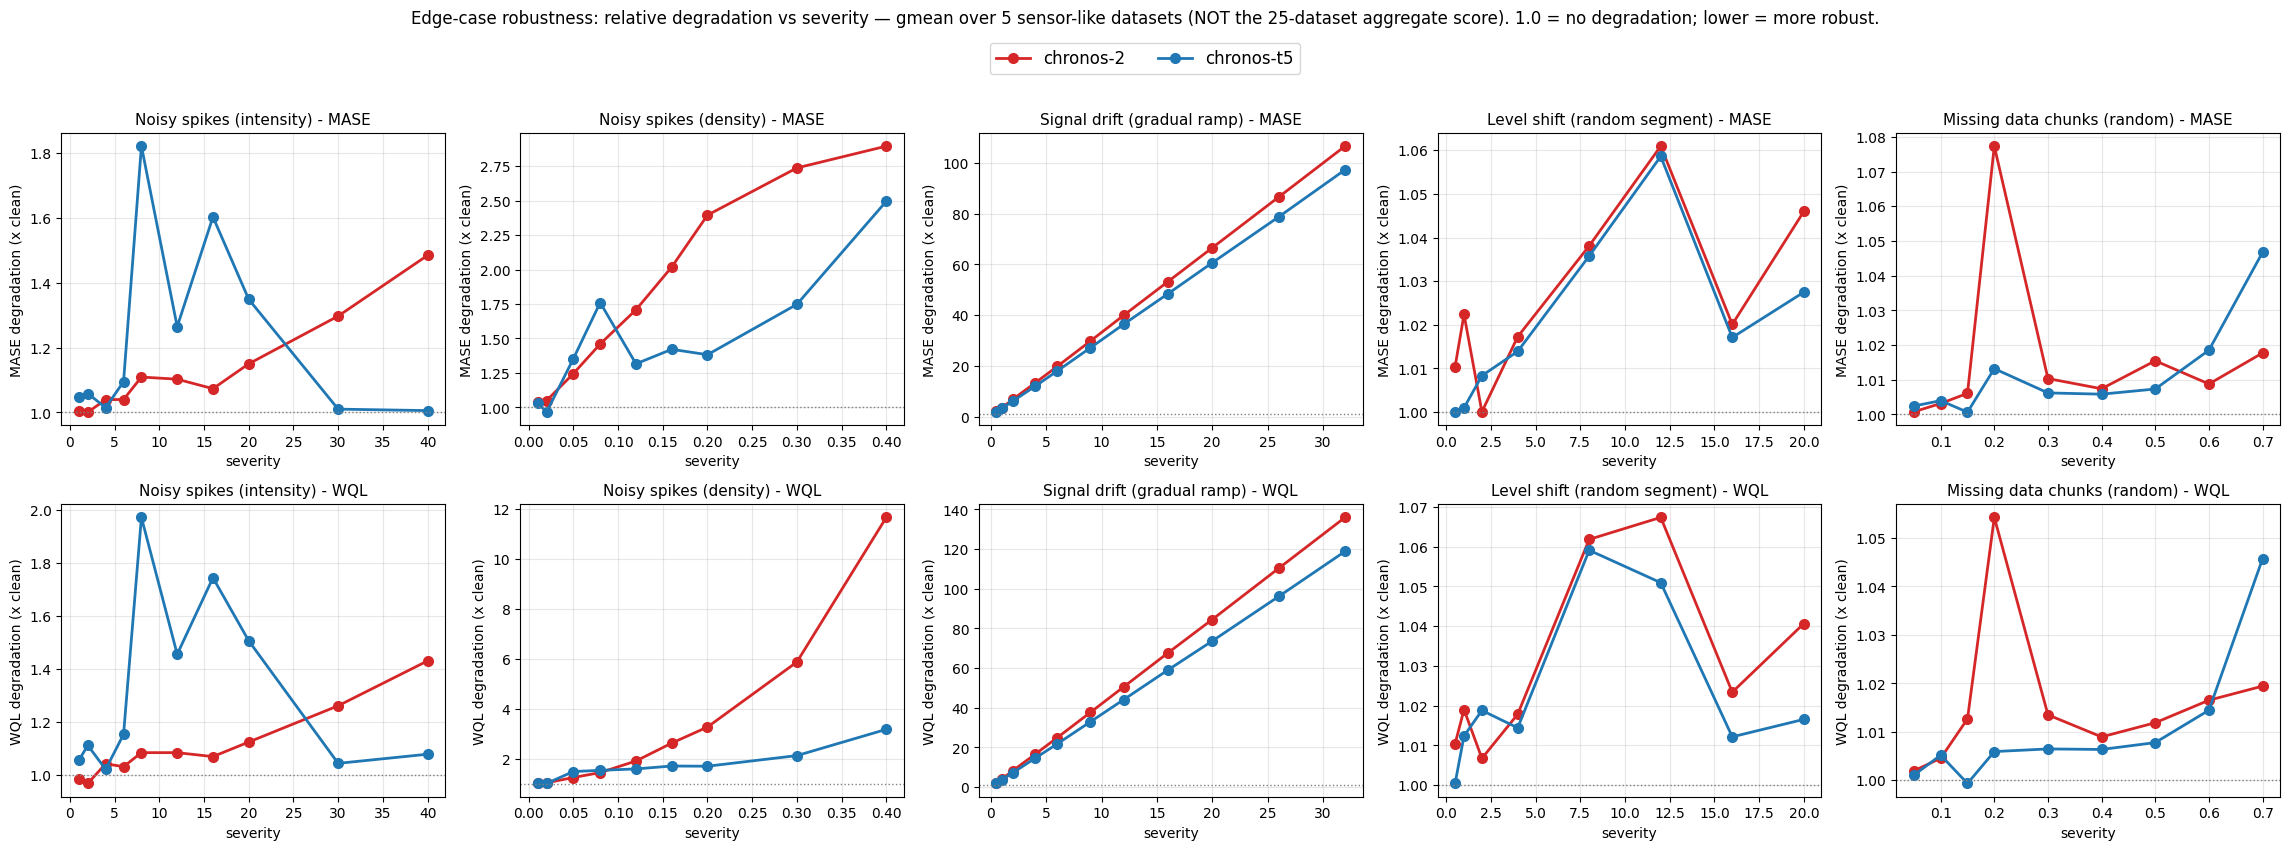

In [6]:
colors = {"chronos-2": "C3", "chronos-t5": "C0"}
nfam = len(E.FAMILIES)
fig, axes = plt.subplots(2, nfam, figsize=(4.6 * nfam, 8.5))
for j, fam in enumerate(E.FAMILIES):
    sevs = E.SEVERITIES[fam]
    for i, (metric, col) in enumerate([("MASE", "MASE_degr"), ("WQL", "WQL_degr")]):
        ax = axes[i, j]
        for model in ["chronos-2", "chronos-t5"]:
            y = [agg_degr(raw, model, fam, s, col) for s in sevs]
            ax.plot(sevs, y, "o-", color=colors[model], lw=2, ms=7, label=model)
        ax.axhline(1.0, color="grey", ls=":", lw=1)
        ax.set_title(f"{TITLE[fam]} - {metric}", fontsize=11)
        ax.set_xlabel("severity"); ax.set_ylabel(f"{metric} degradation (x clean)")
        ax.grid(alpha=0.3)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=2, fontsize=12)
fig.suptitle(f"Edge-case robustness: relative degradation vs severity — gmean over "
             f"{len(E.EDGE_DATASETS)} sensor-like datasets (NOT the 25-dataset aggregate score). "
             f"1.0 = no degradation; lower = more robust.", fontsize=12, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

### 5.1 Full degradation table (every severity)

In [7]:
recs = []
for fam in E.FAMILIES:
    for sev in E.SEVERITIES[fam]:
        recs.append({"corruption": TITLE[fam], "severity": sev,
                     "C2 MASE": agg_degr(raw, "chronos-2", fam, sev, "MASE_degr"),
                     "T5 MASE": agg_degr(raw, "chronos-t5", fam, sev, "MASE_degr"),
                     "C2 WQL":  agg_degr(raw, "chronos-2", fam, sev, "WQL_degr"),
                     "T5 WQL":  agg_degr(raw, "chronos-t5", fam, sev, "WQL_degr")})
pd.DataFrame(recs)

,corruption,severity,C2 MASE,T5 MASE,C2 WQL,T5 WQL
0,Noisy spikes (intensity),1.0000,1.0046,1.0486,0.9871,1.0556
1,Noisy spikes (intensity),2.0000,1.0006,1.0582,0.9686,1.1123
2,Noisy spikes (intensity),4.0000,1.0392,1.0145,1.0427,1.0217
3,Noisy spikes (intensity),6.0000,1.0396,1.0947,1.0318,1.1536
4,Noisy spikes (intensity),8.0000,1.1089,1.8211,1.0847,1.9724
5,Noisy spikes (intensity),12.0000,1.1023,1.2643,1.0846,1.4560
6,Noisy spikes (intensity),16.0000,1.0730,1.6028,1.0698,1.7446
7,Noisy spikes (intensity),20.0000,1.1497,1.3486,1.1248,1.5067
8,Noisy spikes (intensity),30.0000,1.2970,1.0100,1.2616,1.0443
9,Noisy spikes (intensity),40.0000,1.4842,1.0055,1.4310,1.0788


## 6. Example behaviour (saved figures)

For each example dataset (`ercot`, `monash_traffic`, `nn5`) `run_edge_cases.py` saves **six
figures** into `results/examples/<dataset>/` — one per corruption category. Every
figure has **4 panels: clean context + 3 increasing severities**, with both models' forecasts
(Chronos-2 red solid, Chronos-T5 blue dashed; p50 + 10-90% band) over the **clean held-out
actual** (green). A fixed recent window keeps the forecast **horizon** clearly visible.

The six categories (spikes is split into two **controlled-variable** figures):
* **`spikes_intensity`** (×10/20/30, density fixed 5%) — *same* spike positions growing taller.
* **`spikes_density`** (2/5/10%, magnitude fixed ×20) — *more* spikes (nested) at fixed height.
* **`drift_ramp`** (×10/20/30) — a ramp reaching the origin; **harmful** (forecast dragged off).
* **`level_shift`** (×10/20/30) — a shifted random past segment; **harmless** (recent tail intact).
* **`missing_random`** (10/20/30%) — a gap at a random past position; **harmless**.
* **`missing_boundary`** (10/20/30%) — a gap pinned to the **context|horizon junction**
  (most-recent dropout); **harmful**, the placement contrast vs `missing_random`.

Below, `nn5` is shown for all six (clearest); the other datasets' figures are on disk.

nn5 / spikes_intensity


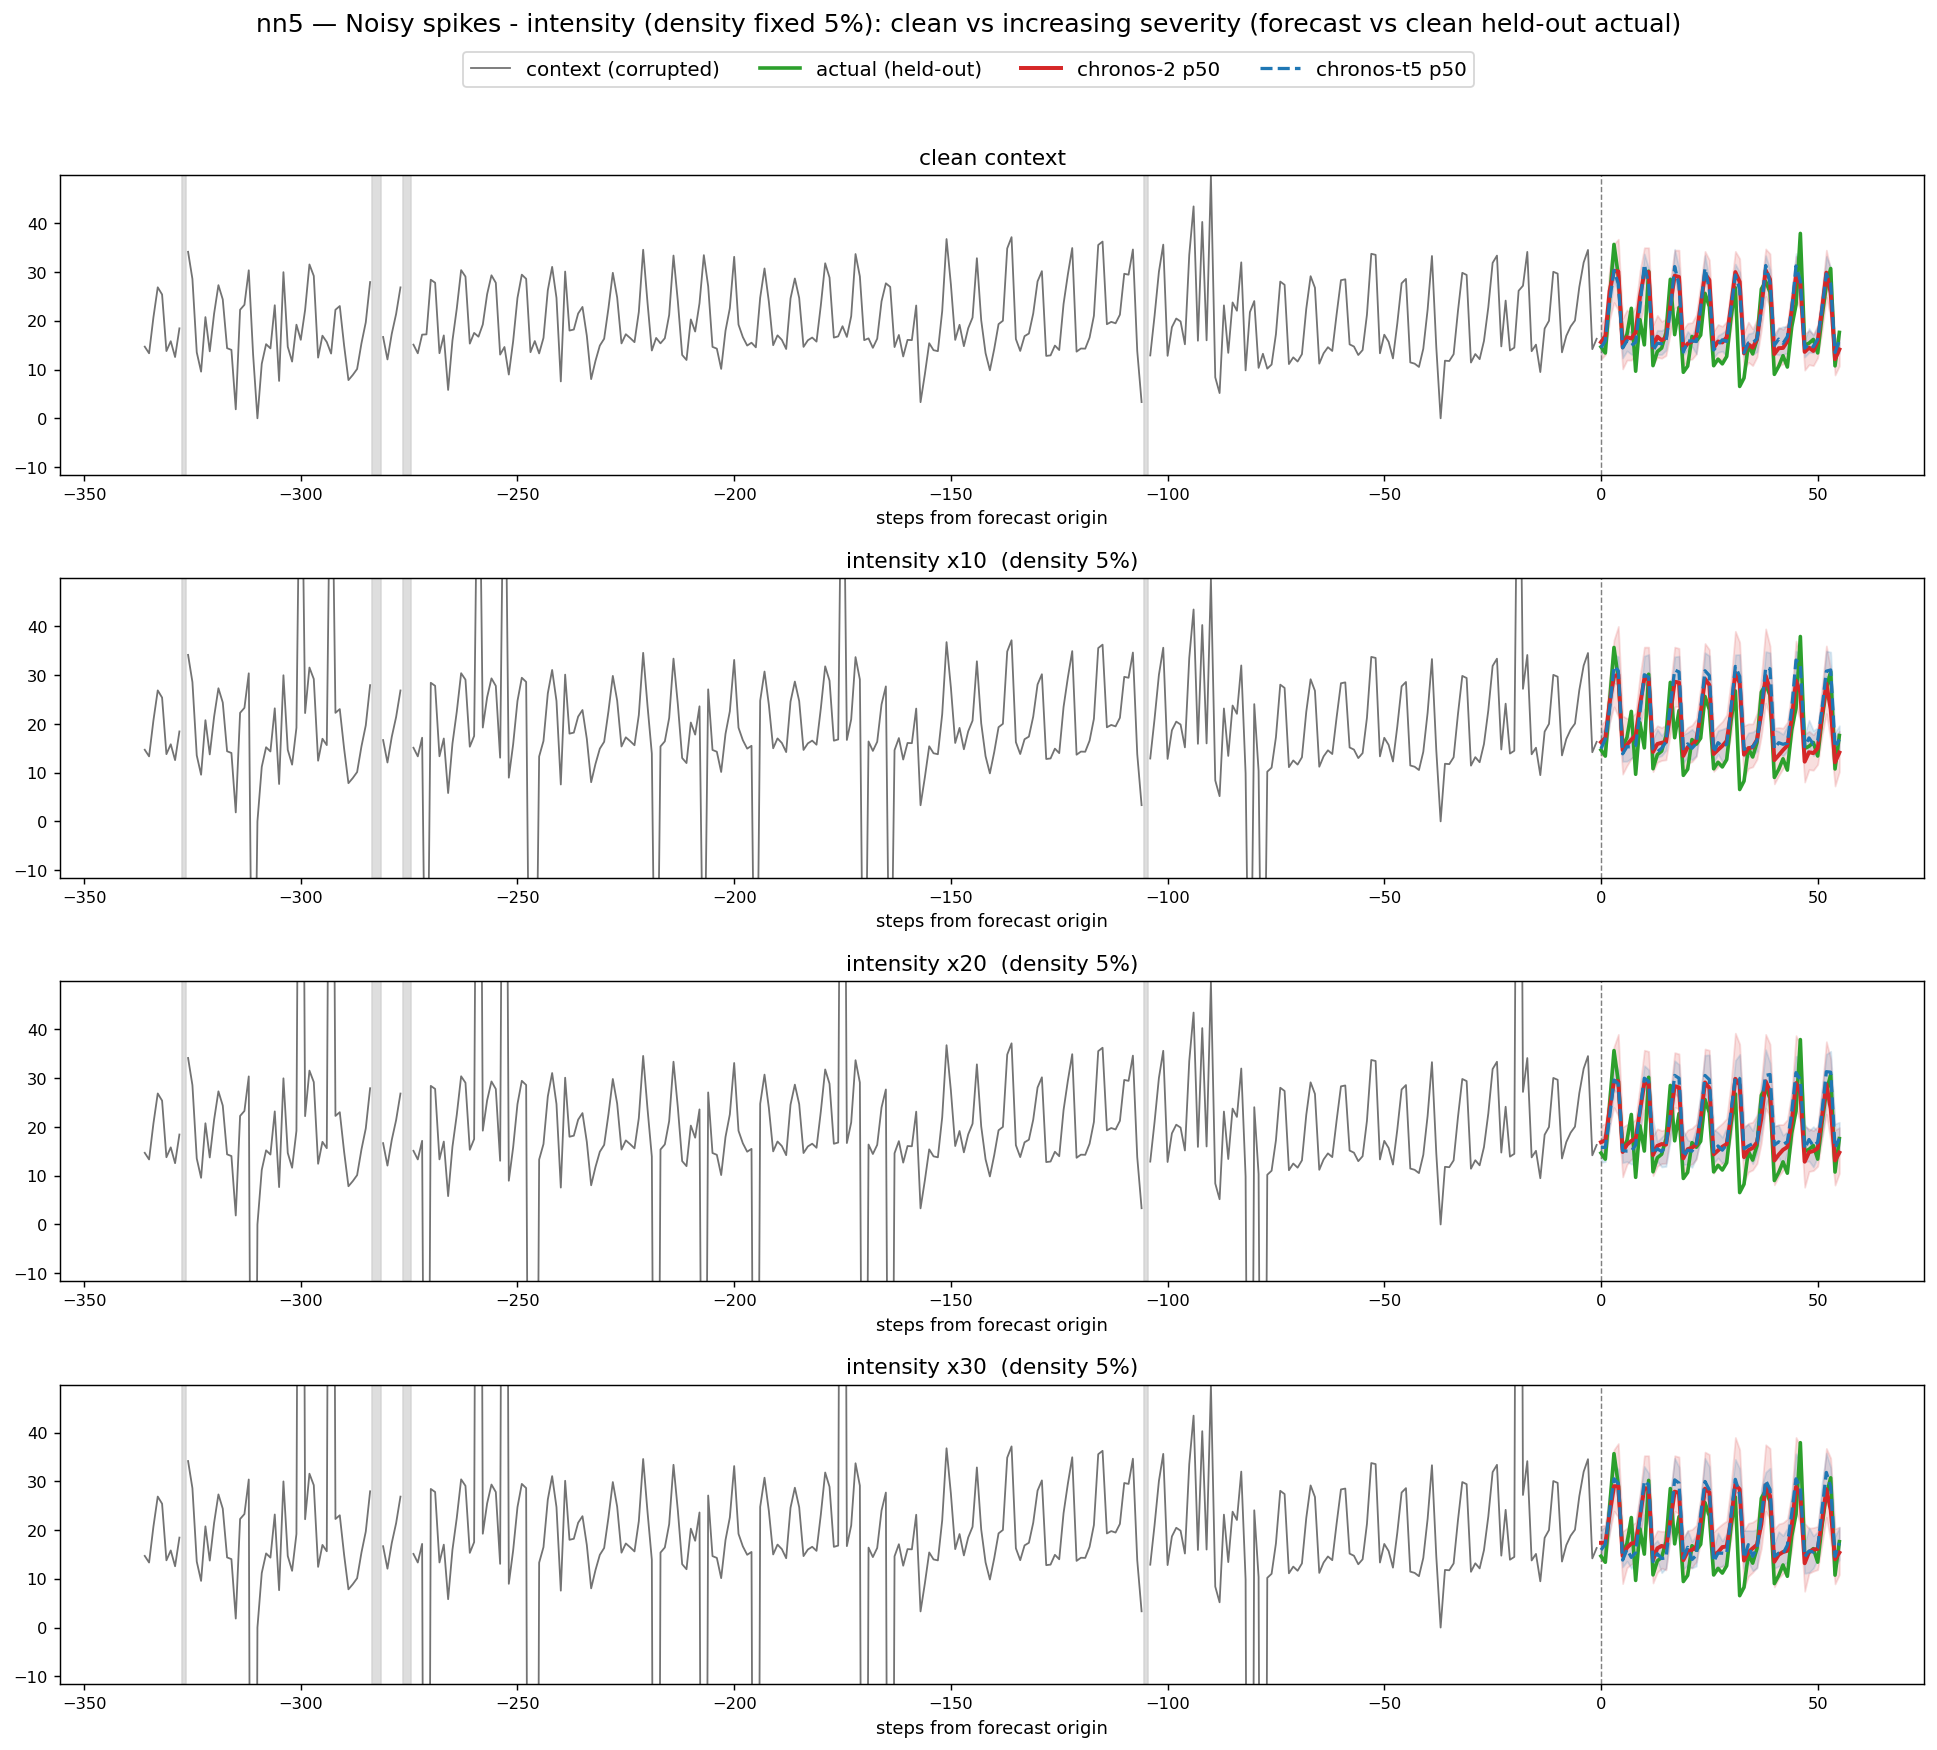

nn5 / spikes_density


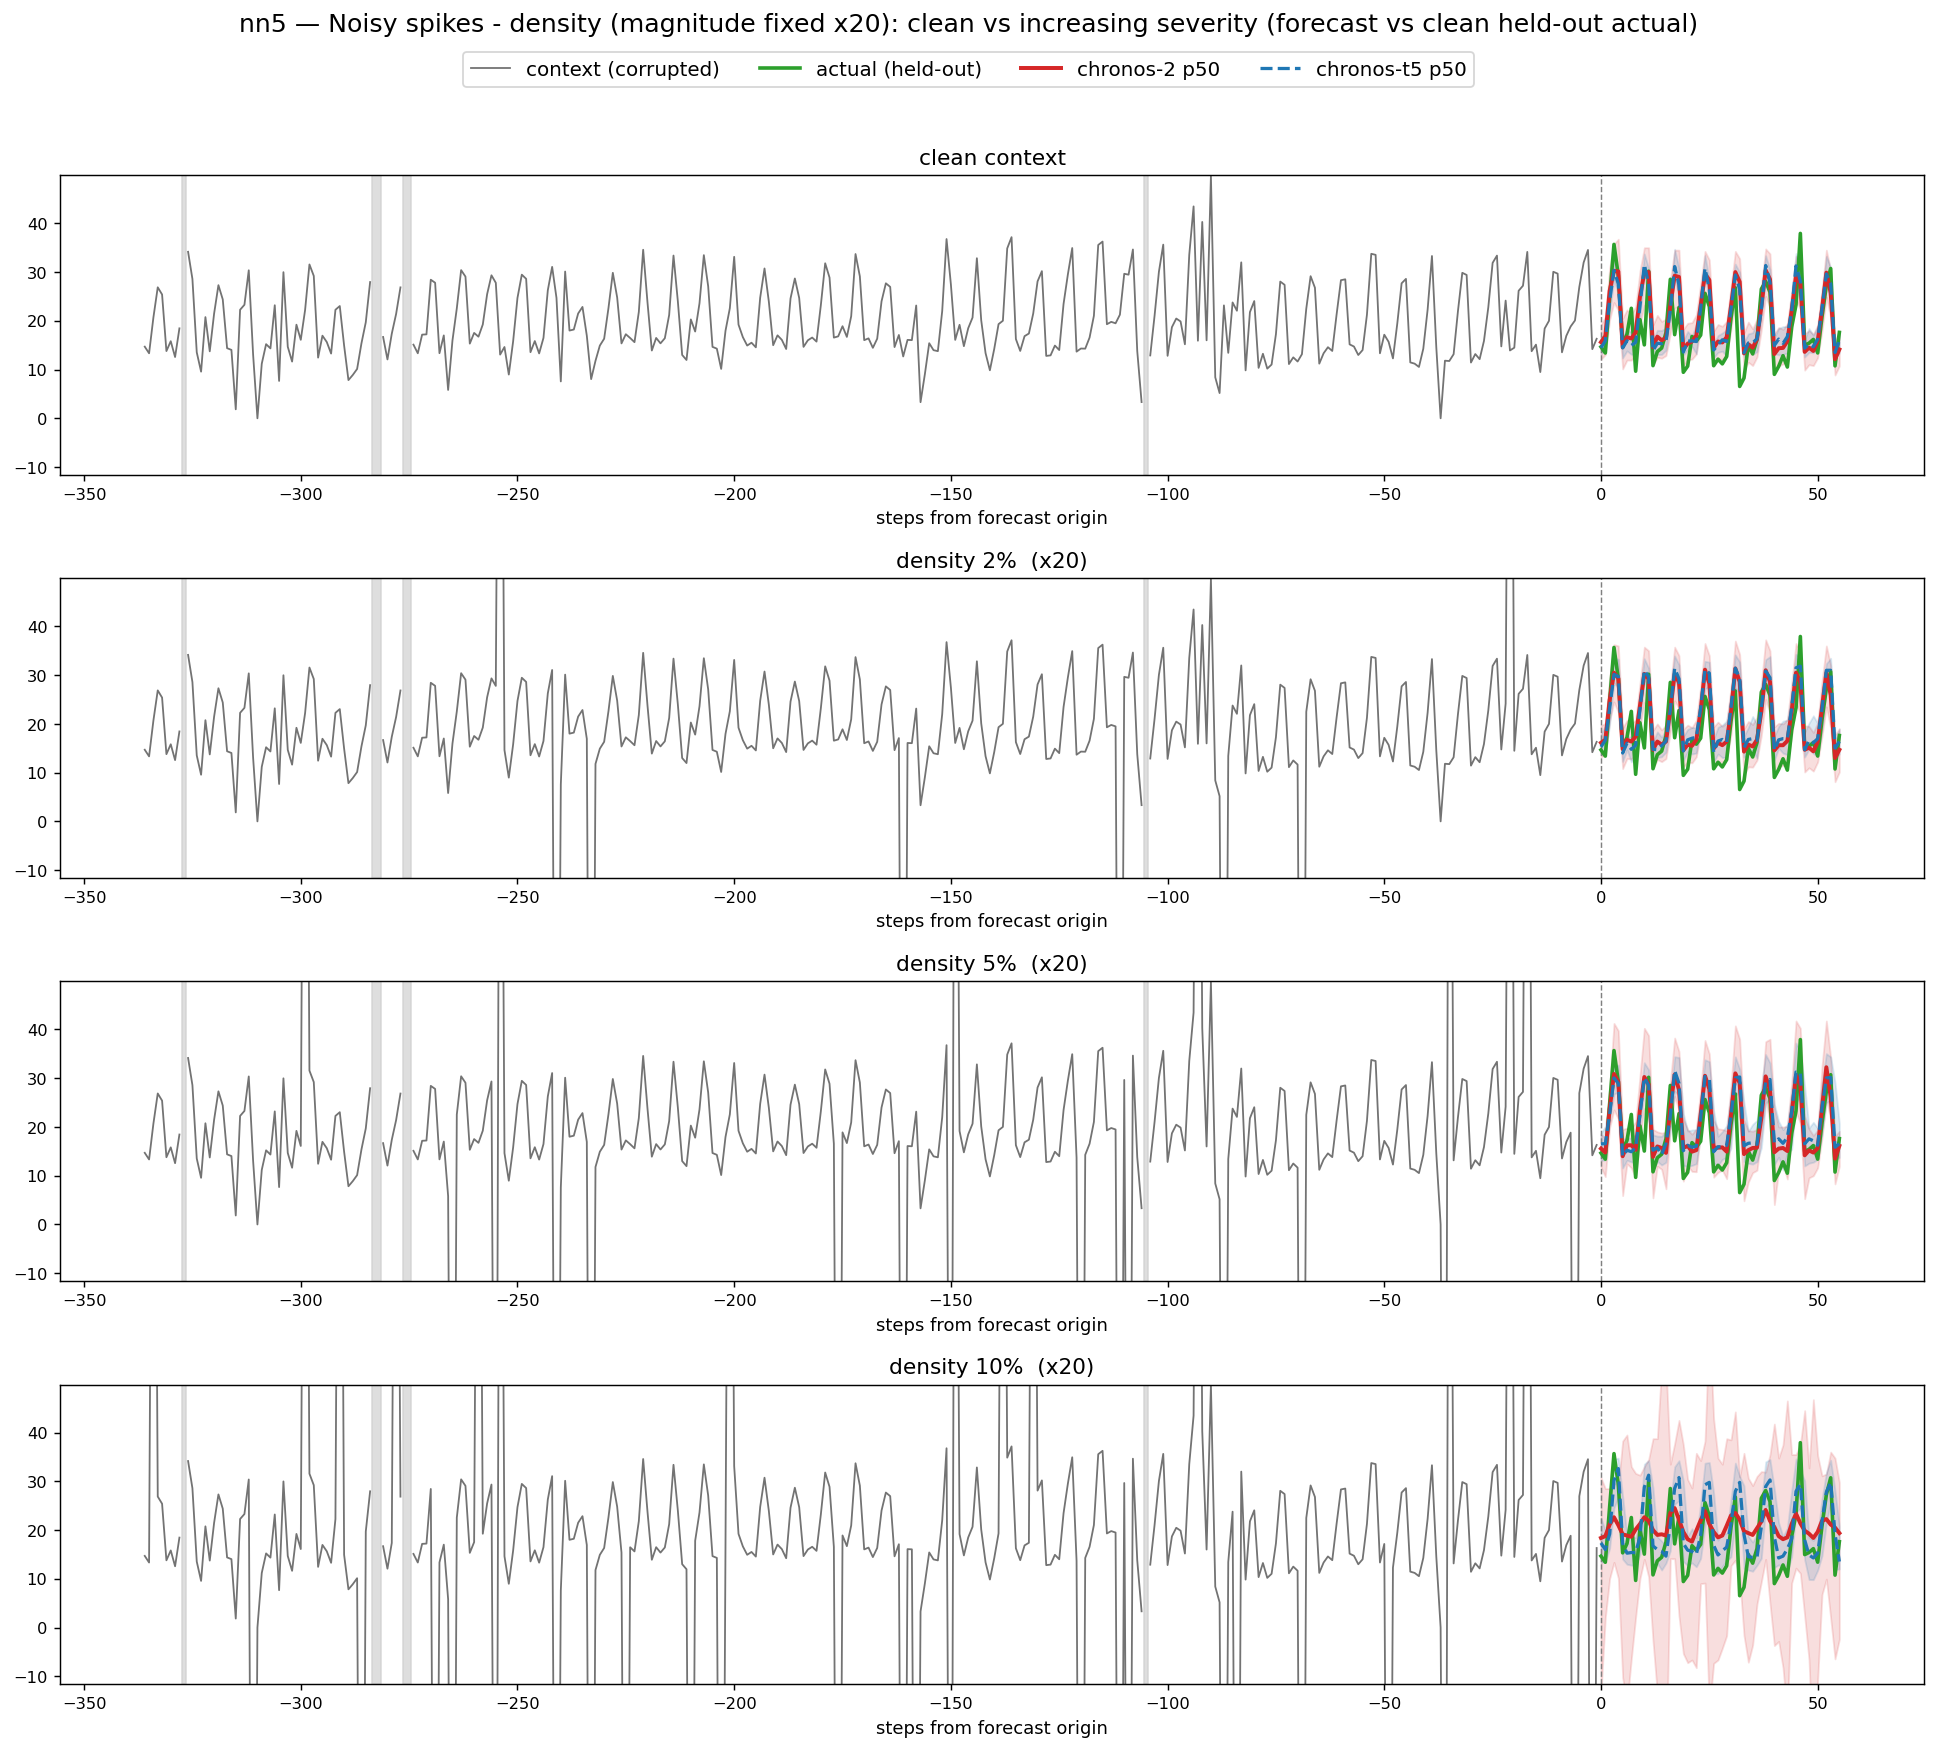

nn5 / drift_ramp


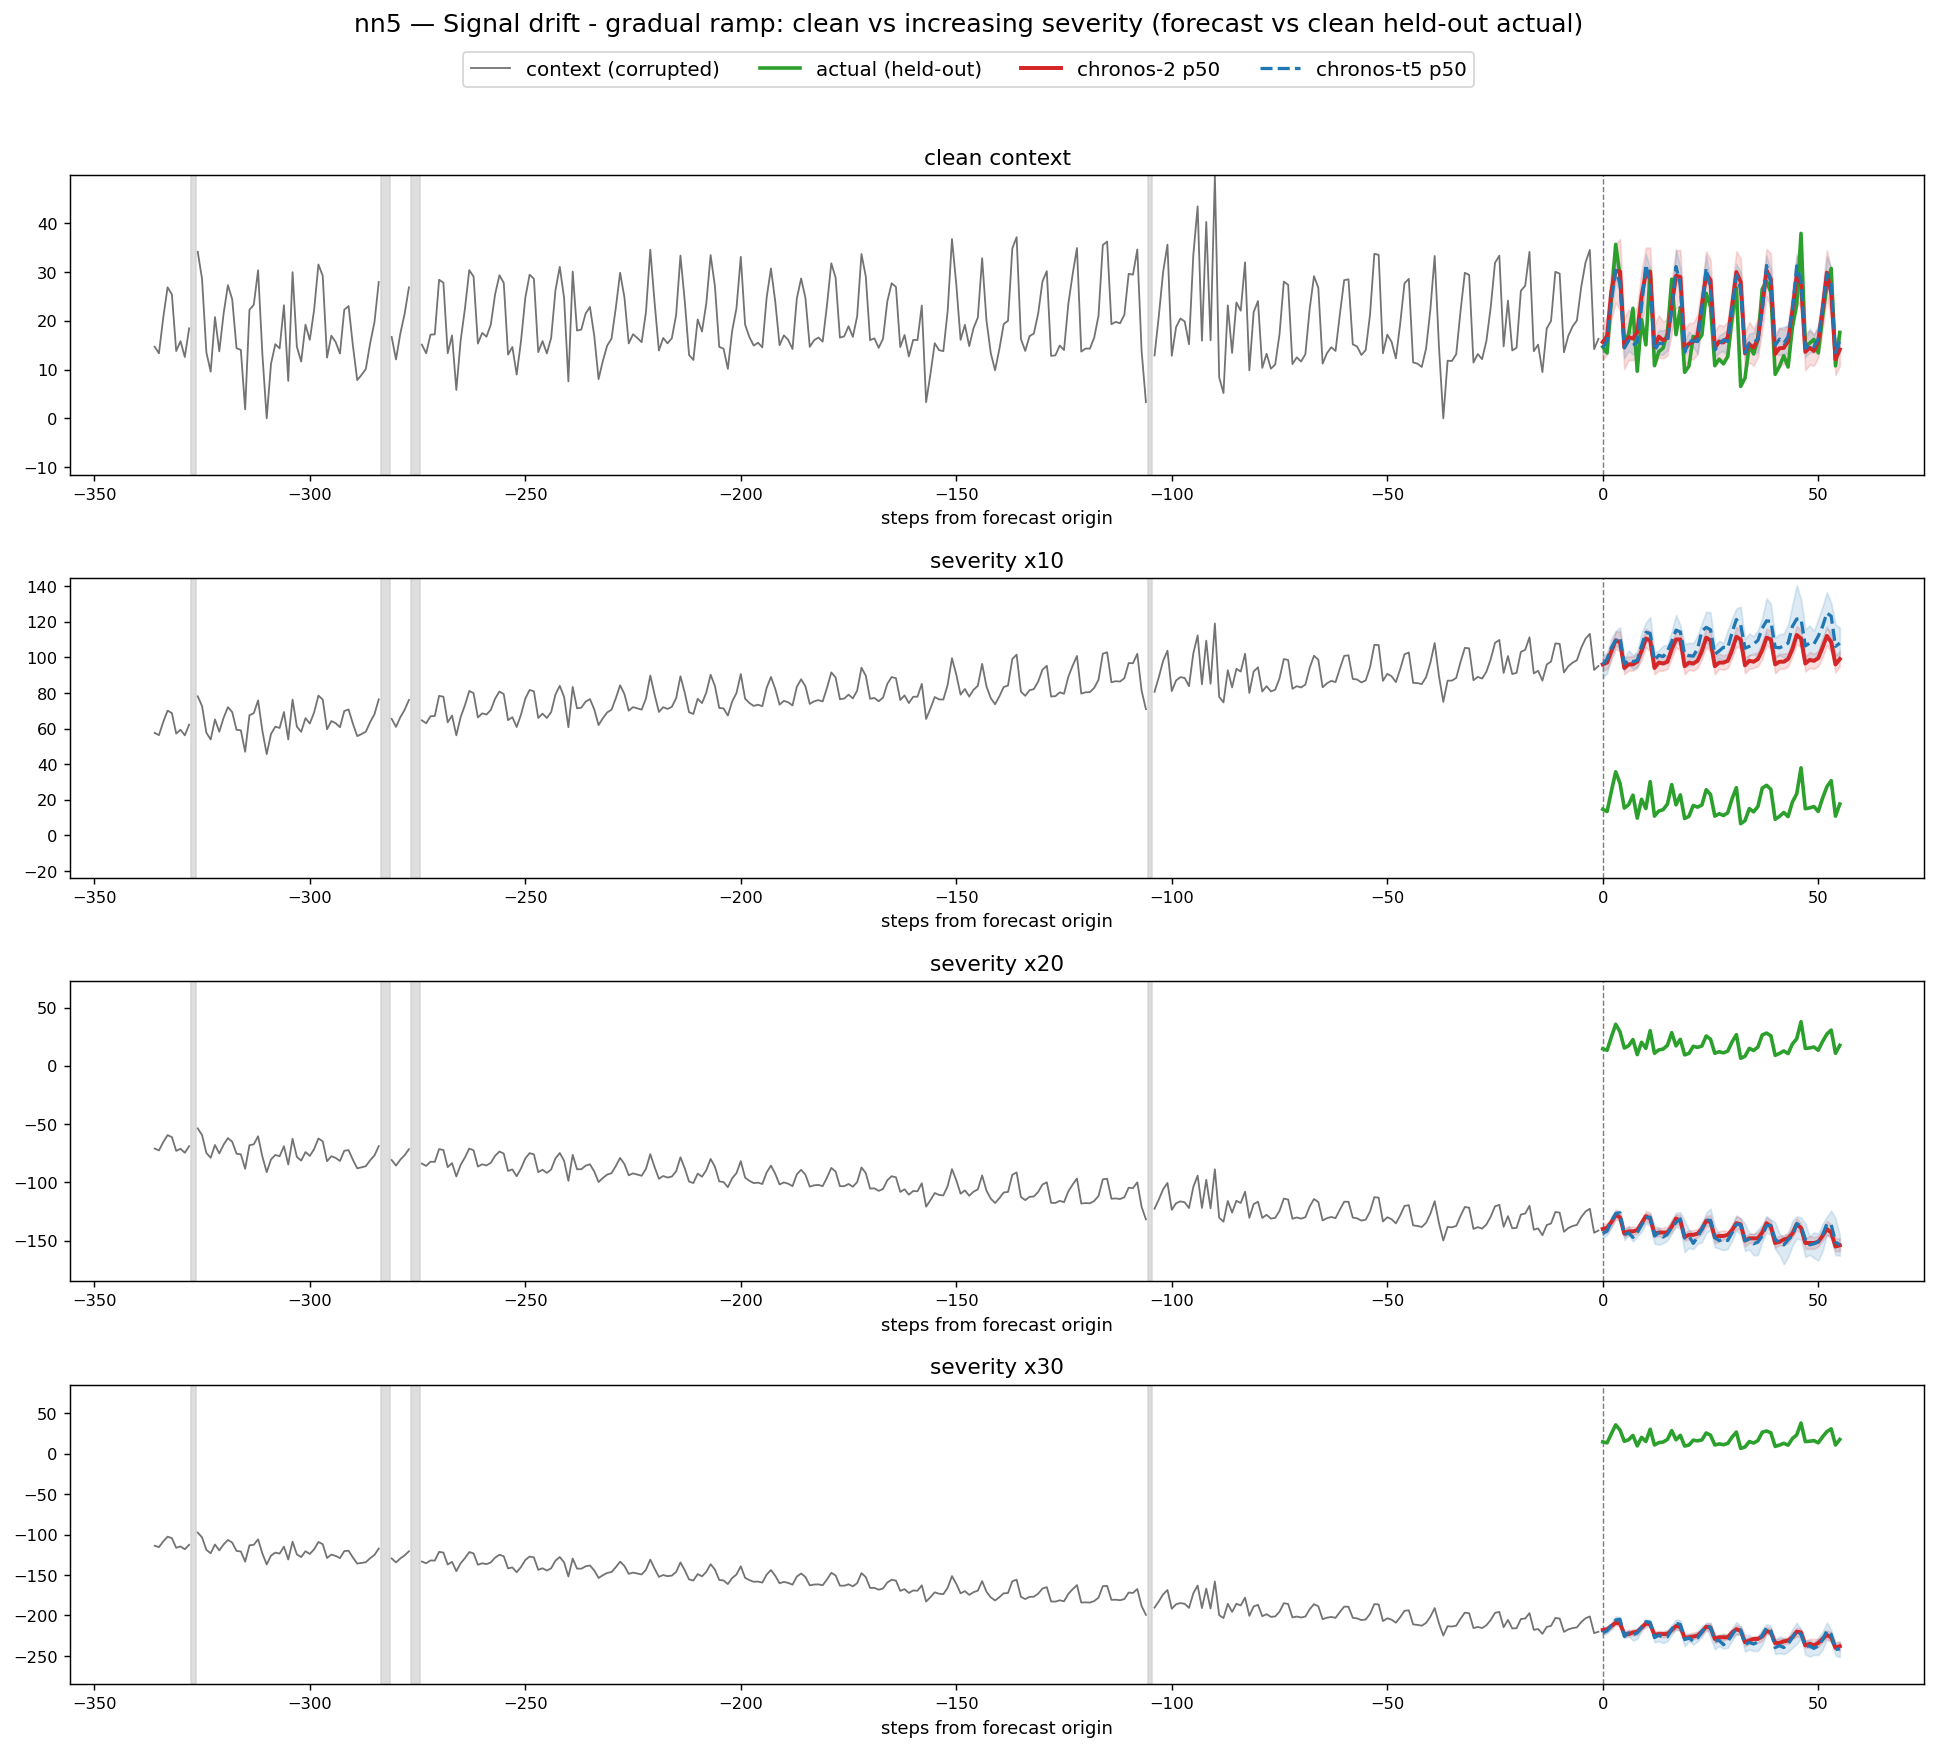

nn5 / level_shift


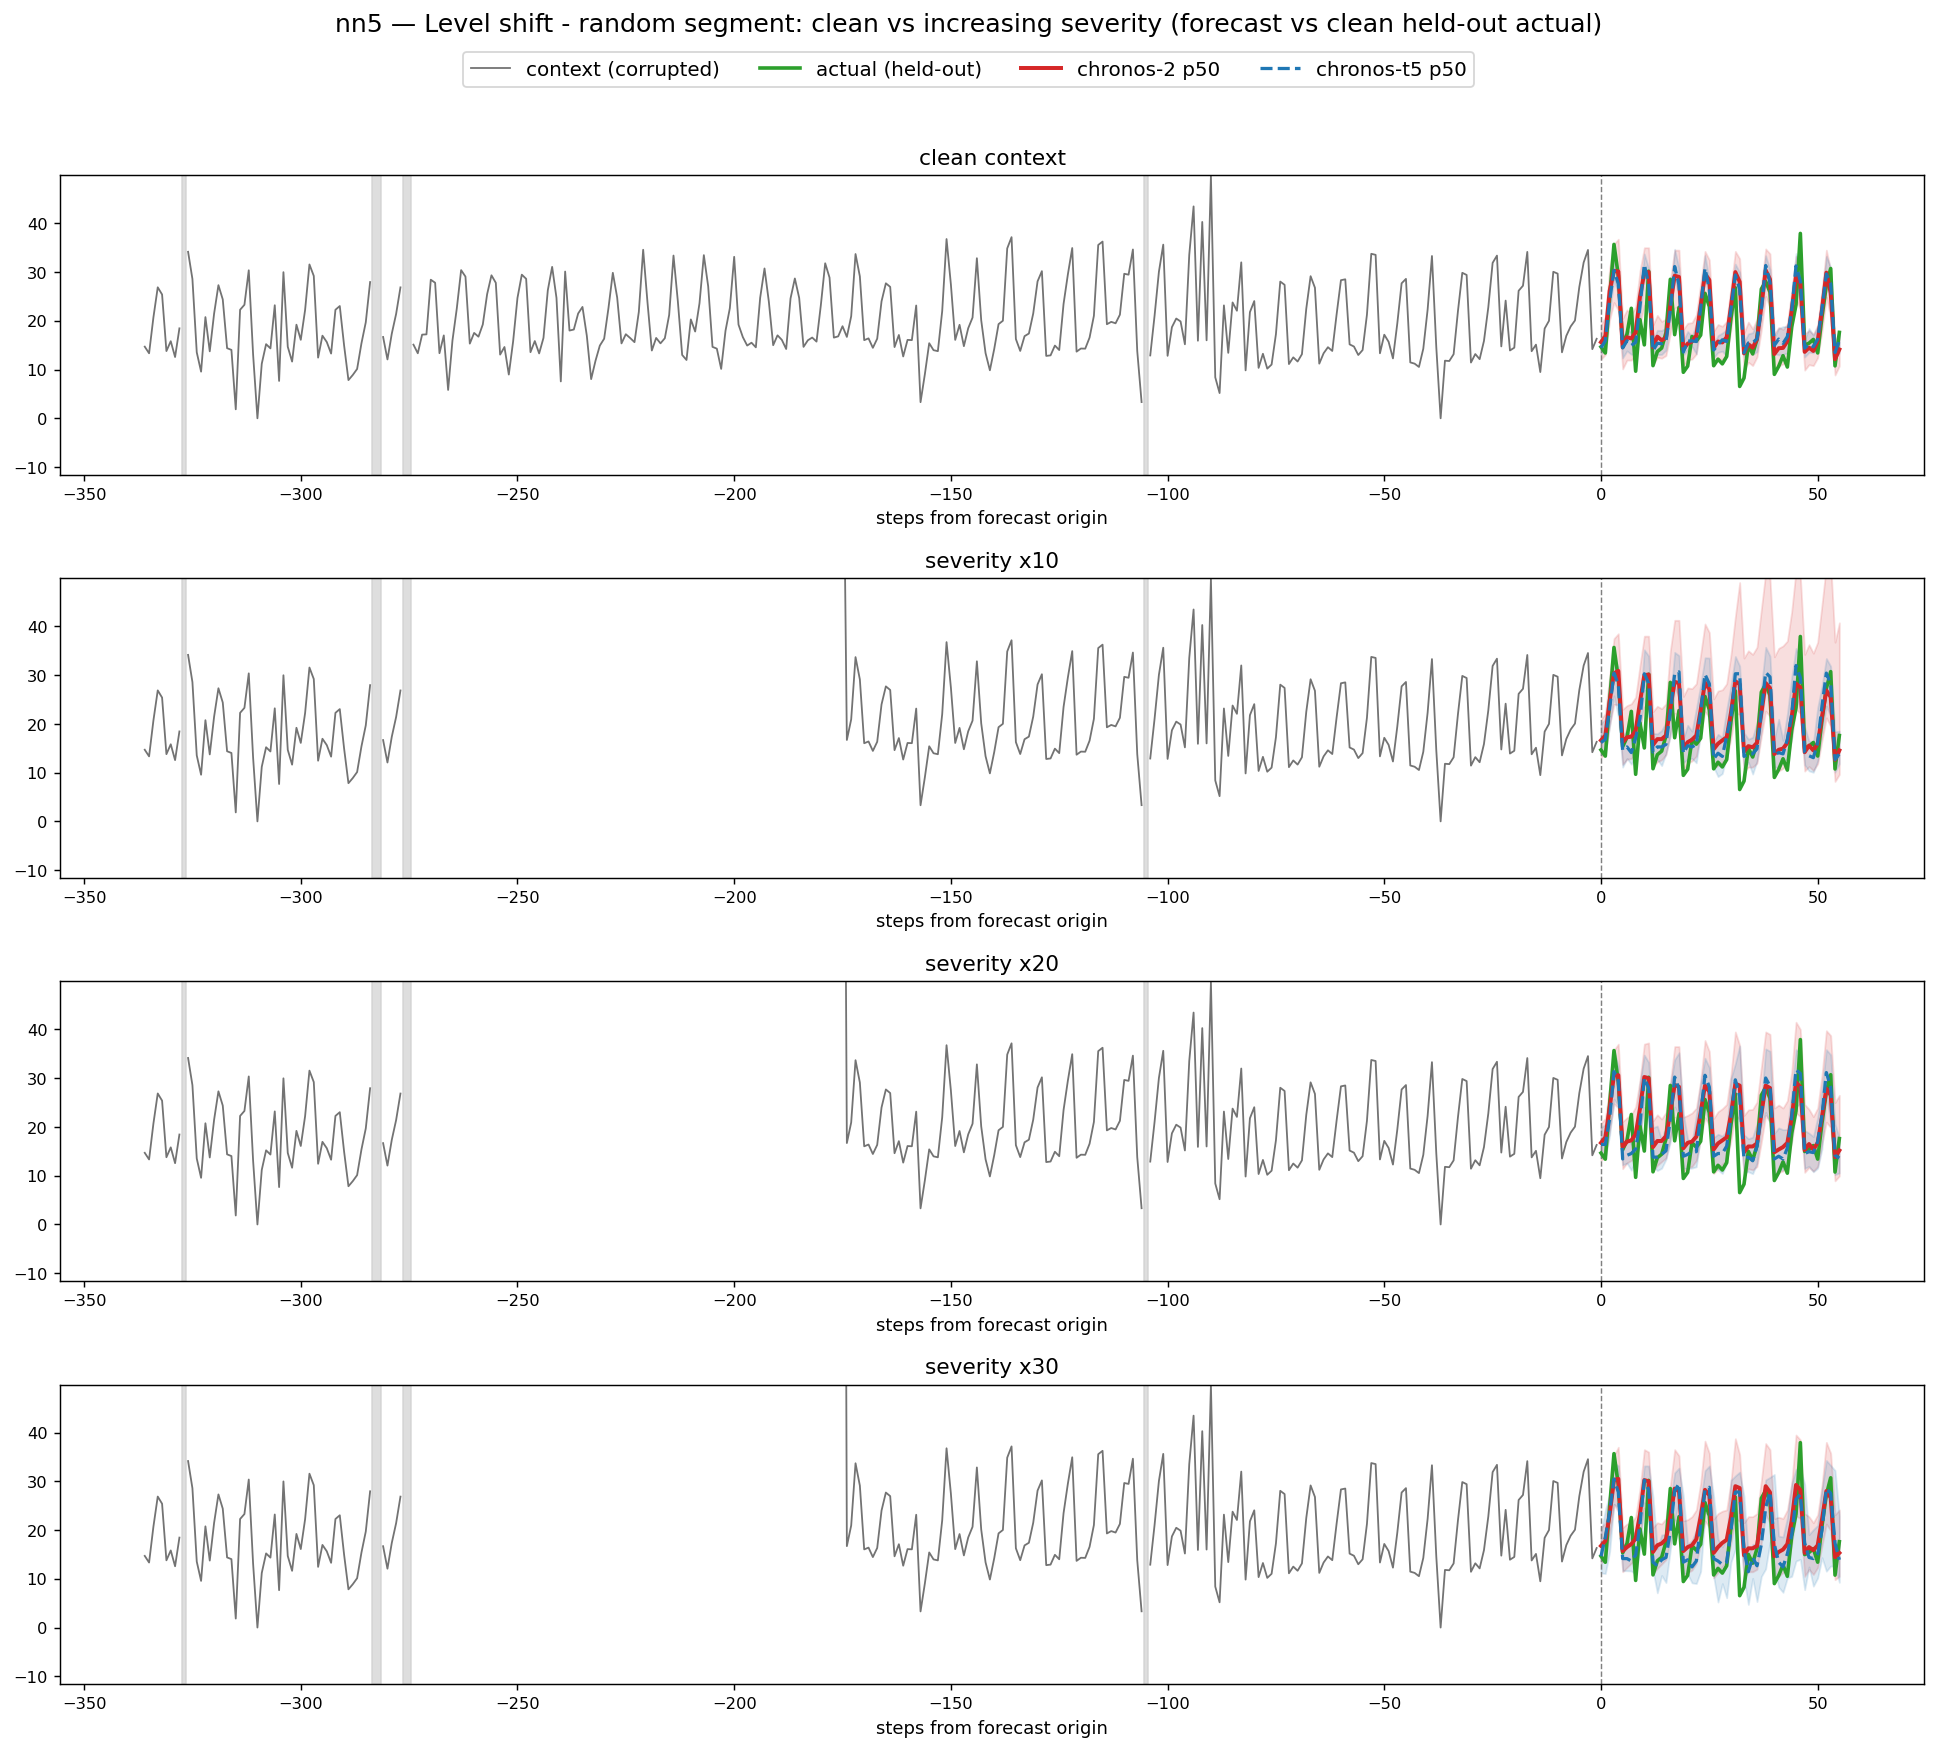

nn5 / missing_random


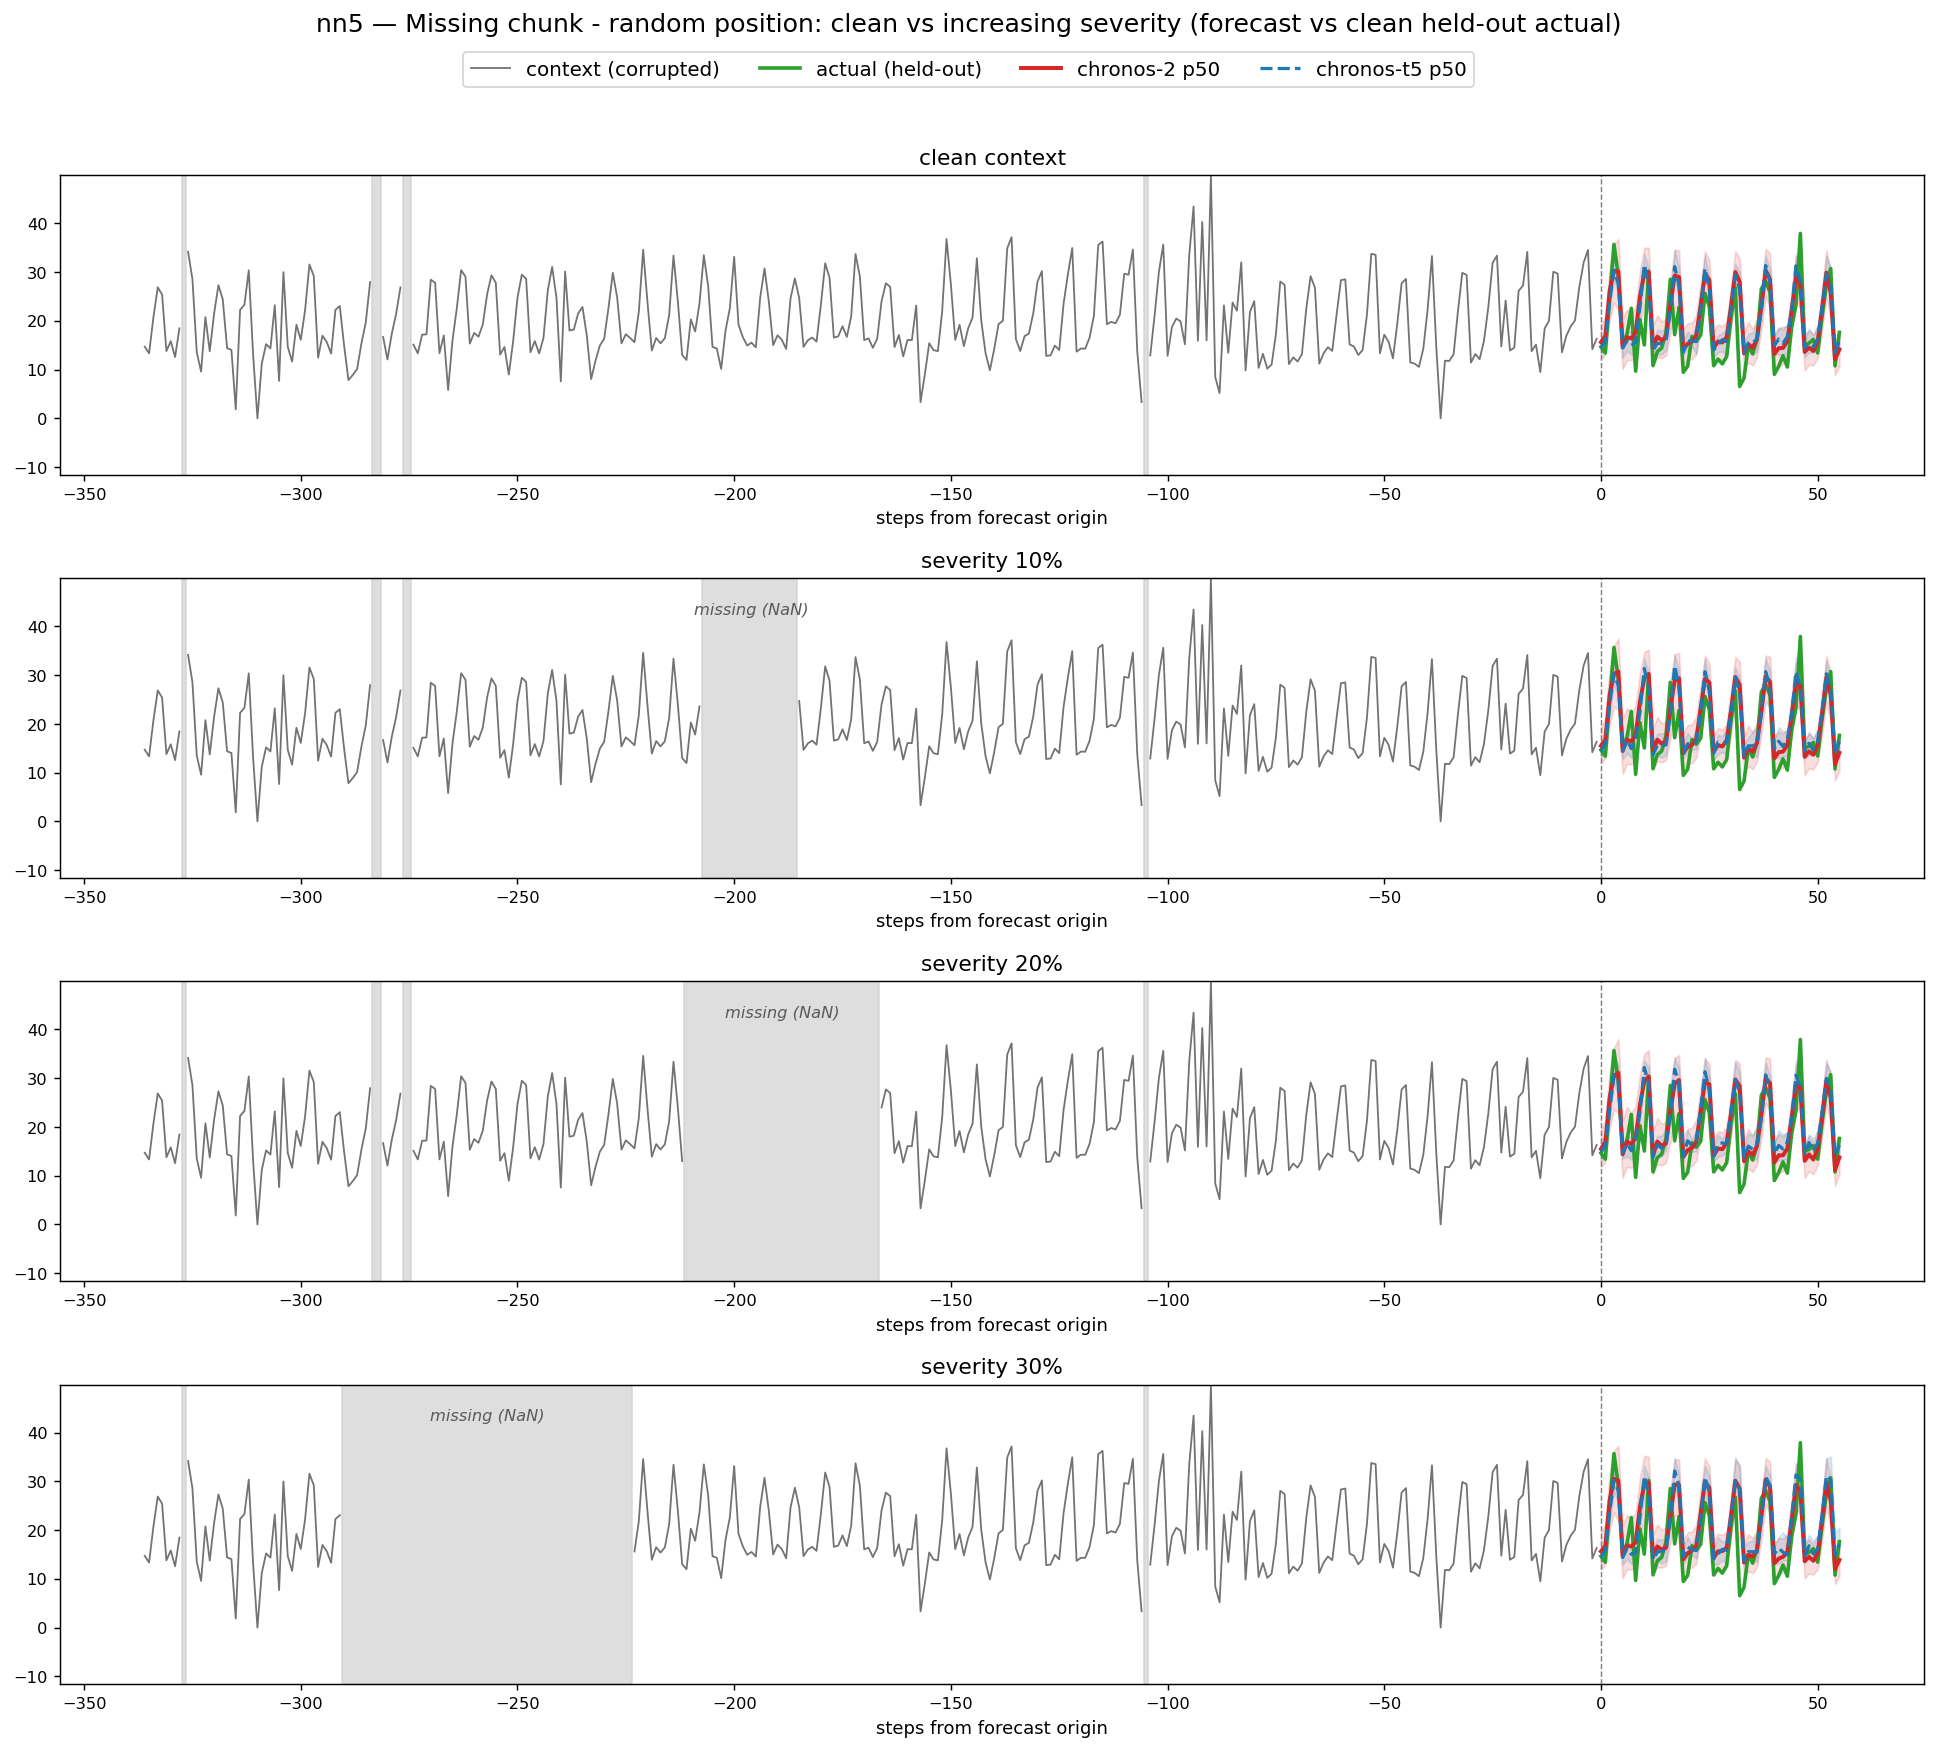

nn5 / missing_boundary


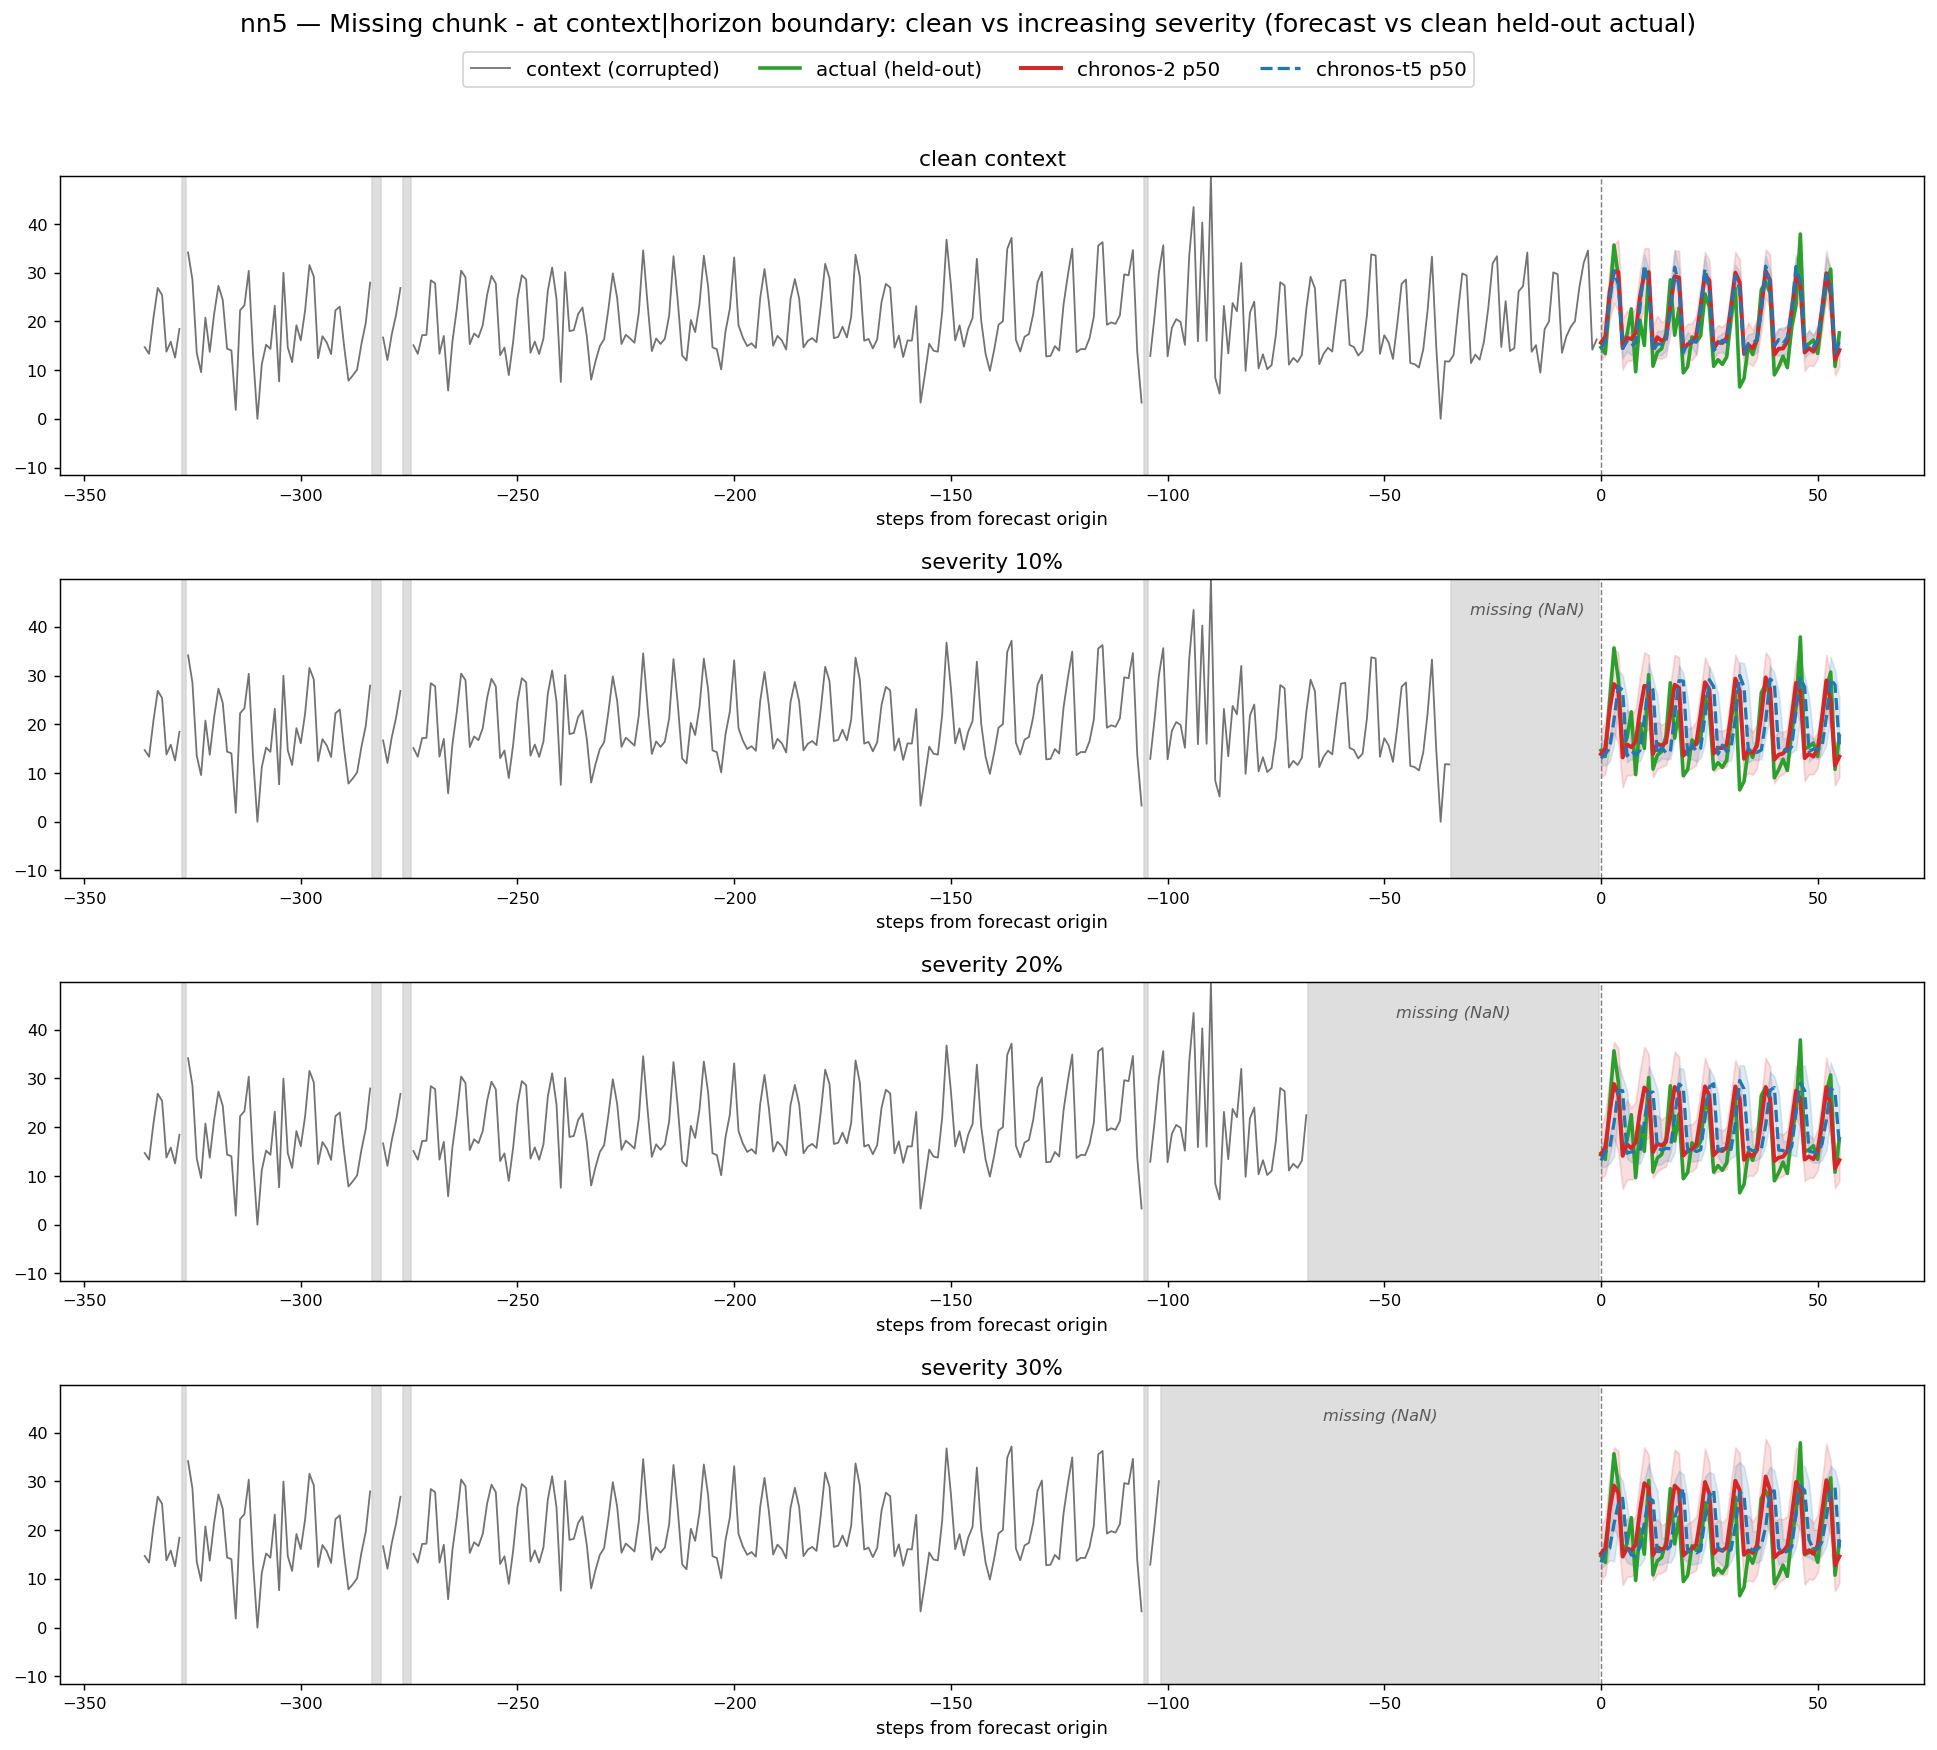

Other datasets: ['ercot', 'monash_traffic'] -> see results/examples/<dataset>/


In [8]:
CATS = ["spikes_intensity", "spikes_density", "drift_ramp", "level_shift",
        "missing_random", "missing_boundary"]
SHOW = "nn5"
for cat in CATS:
    img = EDGE / "examples" / SHOW / f"{cat}.png"
    if img.exists():
        print(f"{SHOW} / {cat}"); display(Image(filename=str(img)))
    else:
        print("run run_edge_cases.py first:", img)
print("Other datasets:", [d for d in E.EXAMPLE_DATASETS if d != SHOW],
      "-> see results/examples/<dataset>/")

## 7. Live demo — placement matters (worst-case recent gap)

A small live check (loads both models): forecast a single sensor series from a **clean** context
vs a **most-recent-50%-gap** context (`position="recent"`, the worst case — deliberately
*different* from the study's random-position gaps, which are benign). This shows the other end of
the placement spectrum: blanking the recent context, the part the model anchors to, is far more
damaging than a random gap in the past. (Skipped automatically if no GPU/weights.)

In [9]:
try:
    from chronos import BaseChronosPipeline

    cfg, H = "ercot", 24
    test_data, contexts, starts = E.build_dataset(cfg, H)
    si = int(max(range(len(contexts)), key=lambda i: np.isfinite(contexts[i]).sum()))
    clean_ctx = contexts[si]
    gap_ctx = P.drop_chunk(clean_ctx, np.random.default_rng(0), fraction=0.50, position="recent")
    label_arr = np.asarray(list(test_data.label)[si]["target"], dtype=np.float32)

    for name, mid, kind in E.MODELS:
        pipe = BaseChronosPipeline.from_pretrained(mid, device_map="cuda", torch_dtype=E.R2.DTYPE)
        fc_c = E.forecast(pipe, [clean_ctx], [starts[si]], H, kind)[0]
        fc_g = E.forecast(pipe, [gap_ctx],  [starts[si]], H, kind)[0]
        import numpy as _np
        def mase_like(fc):  # quick |p50 - actual| mean (illustrative, not the gluonts MASE)
            return float(_np.mean(_np.abs(fc.forecast_array[4] - label_arr)))
        print(f"{name:11s} clean |p50-actual|={mase_like(fc_c):.3f}  gap50%={mase_like(fc_g):.3f}")
        del pipe; torch.cuda.empty_cache()
except Exception as e:
    print("live demo skipped:", type(e).__name__, e)

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


chronos-2   clean |p50-actual|=306.257  gap50%=17220.869


chronos-t5  clean |p50-actual|=203.574  gap50%=17220.143


## 8. Findings

**Headline: only corruptions that reach the *recent* context near the forecast origin hurt.**
Both models anchor their forecast to the most recent observations, so damage is governed by
*where* the corruption lands, not just how big it is.

* **Noisy spikes — mild, Chronos-2 clearly more robust** (1.15x vs 1.35x MASE at the worst
  level; C2's curve stays flat while T5 jumps past ~10x scale). C2's patch + InstanceNorm
  front-end absorbs impulses better than T5's quantise-to-token decode.
* **Gradual drift (ramp) — catastrophic for BOTH (~30x).** The ramp is largest exactly at the
  origin, so it corrupts the recent level; both forecast in normalised space and de-normalise
  with the drifted statistics, dragging the prediction up while the true future does not move.
  Per-series normalisation does **not** save them — detrend / bias-correct upstream.
* **Localised level shift (random segment) — essentially harmless (~1.02x for both).** A
  constant offset on a random past 30% segment leaves the recent context intact, so the forecast
  is unaffected. It is not "a level shift" that is dangerous, but one that persists into the
  *recent* window.
* **Missing chunks (random position) — essentially harmless (~1.01x for both).** Both models
  skip a randomly-placed NaN gap and forecast from the surviving recent context. **Placement is
  everything:** the §7 demo blanks the *most-recent* 50% instead, which is far more damaging —
  random dropout in the past is benign, a sensor going dark right before "now" is not.

Full write-up + per-dataset tables: `results/EDGE_CASE_REPORT.md`. Clean-context
(uncorrupted) accuracy and the broader zero-shot head-to-head are in the parent `../`
(`chronos2_t5/zero-shot/`).
